# ARIMA Baseline for ILI HHS Forecasting

This notebook is structured to match the uploaded `LSTM-FM-TensorFlow.ipynb` setup:

- dataset path: `Data/ILINet.csv`
- columns expected: `ds`, `unique_id`, `y`
- look-back window: 52 weeks
- forecasting horizon: 4 weeks
- test windows per time series: 200
- evaluation metrics: MSE, MAE, SMAPE, NNSE, and R²

The model is a classical univariate ARIMA baseline. It fits one ARIMA model at each forecast origin and predicts the next 4 horizons.

## 1. Optional installation

Run this cell only if `statsmodels` or `tqdm` is not installed in your environment.

In [14]:
# Uncomment if needed:
# !pip install statsmodels tqdm scikit-learn

## 2. Imports

In [15]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

## 3. Configuration

In [27]:
# -----------------------------
# Data and forecasting setup
# -----------------------------
PATH_TO_DATA = "Data/ILINet.csv"

PAST = 104
FUTURE = 4
TEST_WINDOWS_PER_SERIES = 200

# -----------------------------
# ARIMA setup
# -----------------------------
# ARIMA(p, d, q). Start with a small order for speed and stability.
# You can try: (1,0,0), (2,0,0), (1,0,1), (2,0,1), (2,0,2)
ARIMA_ORDER = (1, 0, 1)

# Trend options in statsmodels ARIMA: "n" no trend, "c" constant, "t" linear trend, "ct" constant + linear trend.
ARIMA_TREND = "c"

# False = fit ARIMA using only the 52-point look-back window, directly comparable to the LSTM input.
# True  = fit ARIMA using all available history up to each forecast origin.
USE_FULL_HISTORY_UP_TO_ORIGIN = False

# For quick debugging, set to a small number like 20.
# For the full experiment, keep None.
FIRST_N_TEST_WINDOWS_PER_SERIES = None

# Output folder
OUTPUT_DIR = Path("results_arima")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 4. Load the dataset

In [17]:
def load_ili_dataframe(path_to_data: str) -> pd.DataFrame:
    """
    Loads the ILI dataset.

    If your repository has Data.Data_Generator_ILI_HHS_TimeSplit.prepare_ILI_data,
    this function uses it first to stay close to your LSTM notebook.
    Otherwise, it falls back to pd.read_csv(path_to_data).
    """
    try:
        from Data.Data_Generator_ILI_HHS_TimeSplit import prepare_ILI_data

        test_size = 0.2
        train_df, test_df, df, data, number_of_time_series, length_time_series, forecasting_horizon, number_of_samples_in_test = prepare_ILI_data(
            path_to_data, test_size
        )
        print("Loaded data using prepare_ILI_data().")
    except Exception as e:
        print("Could not use prepare_ILI_data(). Falling back to pd.read_csv().")
        print("Reason:", repr(e))
        df = pd.read_csv(path_to_data)

    required_cols = {"ds", "unique_id", "y"}
    missing = required_cols.difference(df.columns)
    if missing:
        raise ValueError(f"Dataset must contain columns {required_cols}. Missing columns: {missing}")

    df = df[["ds", "unique_id", "y"]].copy()
    df["ds"] = pd.to_datetime(df["ds"])
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df = df.dropna(subset=["ds", "unique_id", "y"])
    df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

    return df


df = load_ili_dataframe(PATH_TO_DATA)

print(df.head())
print("\nNumber of time series:", df["unique_id"].nunique())
print("Total rows:", len(df))
print("Date range:", df["ds"].min(), "to", df["ds"].max())
print("\nRows per series:")
print(df.groupby("unique_id").size())

Loaded data using prepare_ILI_data().
                             ds unique_id         y
0 1970-01-01 00:00:00.000000001  Region 1  0.905434
1 1970-01-01 00:00:00.000000002  Region 1  1.012450
2 1970-01-01 00:00:00.000000003  Region 1  0.835424
3 1970-01-01 00:00:00.000000004  Region 1  1.093970
4 1970-01-01 00:00:00.000000005  Region 1  0.995161

Number of time series: 10
Total rows: 10000
Date range: 1970-01-01 00:00:00.000000001 to 1970-01-01 00:00:00.000001

Rows per series:
unique_id
Region 1     1000
Region 10    1000
Region 2     1000
Region 3     1000
Region 4     1000
Region 5     1000
Region 6     1000
Region 7     1000
Region 8     1000
Region 9     1000
dtype: int64


## 5. Create test windows

In [18]:
def make_test_windows_for_group(
    group: pd.DataFrame,
    past: int = 52,
    future: int = 4,
    test_windows_per_series: int = 200,
    first_n_test_windows: int | None = None,
):
    """
    Builds rolling windows for one time series.

    Each sample has:
      X:       previous `past` values
      y_true: next `future` values
      origin: timestamp of the last observed value in X

    The last `test_windows_per_series` rolling windows are used as test windows,
    matching the uploaded LSTM notebook.
    """
    group = group.sort_values("ds").reset_index(drop=True)
    values = group["y"].to_numpy(dtype=float)
    dates = group["ds"].to_numpy()

    records = []
    n_possible = len(values) - past - future + 1
    if n_possible <= 0:
        return records

    start_test_window = max(0, n_possible - test_windows_per_series)

    for window_id, i in enumerate(range(start_test_window, n_possible)):
        if first_n_test_windows is not None and window_id >= first_n_test_windows:
            break

        x = values[i : i + past]
        y_true = values[i + past : i + past + future]
        origin_end_idx = i + past - 1

        records.append({
            "unique_id": group.loc[0, "unique_id"],
            "window_id": window_id,
            "start_idx": i,
            "origin_end_idx": origin_end_idx,
            "origin_ds": pd.Timestamp(dates[origin_end_idx]),
            "X": x,
            "y_true": y_true,
        })

    return records


test_records = []
for uid, grp in df.groupby("unique_id", sort=False):
    test_records.extend(
        make_test_windows_for_group(
            grp,
            past=PAST,
            future=FUTURE,
            test_windows_per_series=TEST_WINDOWS_PER_SERIES,
            first_n_test_windows=FIRST_N_TEST_WINDOWS_PER_SERIES,
        )
    )

print("Number of test samples:", len(test_records))
print("Expected full size:", df["unique_id"].nunique() * TEST_WINDOWS_PER_SERIES)

if test_records:
    print("One sample:")
    sample = test_records[0]
    print({k: v for k, v in sample.items() if k not in ["X", "y_true"]})
    print("X shape:", sample["X"].shape)
    print("y_true shape:", sample["y_true"].shape)

Number of test samples: 2000
Expected full size: 2000
One sample:
{'unique_id': 'Region 1', 'window_id': 0, 'start_idx': 693, 'origin_end_idx': 796, 'origin_ds': Timestamp('1970-01-01 00:00:00.000000797')}
X shape: (104,)
y_true shape: (4,)


## 6. Metrics

In [19]:
def compute_smape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.abs(y_true) + np.abs(y_pred) + eps
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denominator)


def compute_nnse(y_true, y_pred, eps: float = 1e-12):
    """
    Normalized Nash-Sutcliffe Efficiency:
      NSE  = 1 - SS_res / SS_tot
      NNSE = 1 / (2 - NSE)

    NNSE is in a more stable scale than NSE. A value closer to 1 is better.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot < eps:
        return np.nan

    nse = 1.0 - ss_res / ss_tot
    return 1.0 / (2.0 - nse)


def summarize_forecasts(y_true, y_pred):
    """
    y_true and y_pred must both have shape:
      (num_test_samples, FUTURE)
    """
    rows = []

    for h in range(y_true.shape[1]):
        yt = y_true[:, h]
        yp = y_pred[:, h]

        rows.append({
            "horizon": h + 1,
            "MSE": mean_squared_error(yt, yp),
            "MAE": mean_absolute_error(yt, yp),
            "SMAPE": compute_smape(yt, yp),
            "NNSE": compute_nnse(yt, yp),
            "R2": r2_score(yt, yp),
        })

    results = pd.DataFrame(rows)

    mean_row = {"horizon": "mean"}
    for col in ["MSE", "MAE", "SMAPE", "NNSE", "R2"]:
        mean_row[col] = results[col].mean()

    results = pd.concat([results, pd.DataFrame([mean_row])], ignore_index=True)
    return results

## 7. ARIMA forecasting functions

In [25]:
def naive_fallback_forecast(history, horizon: int):
    """Fallback forecast used when ARIMA fails: repeat the last observed value."""
    history = np.asarray(history, dtype=float)
    last_value = history[np.isfinite(history)][-1]
    return np.repeat(last_value, horizon)


def arima_forecast_one_origin(
    history,
    horizon: int = 4,
    order: tuple[int, int, int] = (2, 0, 2),
    trend: str = "c",
):
    """
    Fits ARIMA on one history vector and returns a multi-step forecast.

    This is deterministic; unlike LSTM, repeated runs are not needed unless
    you change the ARIMA order or preprocessing.
    """
    history = np.asarray(history, dtype=float)
    history = history[np.isfinite(history)]

    if len(history) < max(10, order[0] + order[1] + order[2] + 5):
        return naive_fallback_forecast(history, horizon), "fallback_short_history"

    try:
        model = ARIMA(
            history,
            order=order,
            trend=trend,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fitted = model.fit(method_kwargs={"maxiter": 200})
        forecast = np.asarray(fitted.forecast(steps=horizon), dtype=float)

        if len(forecast) != horizon or not np.all(np.isfinite(forecast)):
            return naive_fallback_forecast(history, horizon), "fallback_bad_forecast"

        return forecast, "arima"

    except Exception:
        return naive_fallback_forecast(history, horizon), "fallback_exception"


def run_arima_on_test_records(
    df: pd.DataFrame,
    test_records: list[dict],
    order: tuple[int, int, int] = (1, 0, 1),
    trend: str = "c",
    use_full_history_up_to_origin: bool = False,
    horizon: int = 4,
):
    """
    Runs ARIMA for all test records.

    If use_full_history_up_to_origin=False:
        history = the same 52-week X window used by the LSTM.

    If use_full_history_up_to_origin=True:
        history = all observations from that region up to the forecast origin.
    """
    series_values = {
        uid: grp.sort_values("ds")["y"].to_numpy(dtype=float)
        for uid, grp in df.groupby("unique_id", sort=False)
    }

    predictions = []
    statuses = []

    for rec in tqdm(test_records, desc="Running ARIMA"):
        uid = rec["unique_id"]

        if use_full_history_up_to_origin:
            history = series_values[uid][: rec["origin_end_idx"] + 1]
        else:
            history = rec["X"]

        forecast, status = arima_forecast_one_origin(
            history=history,
            horizon=horizon,
            order=order,
            trend=trend,
        )
        predictions.append(forecast)
        statuses.append(status)

    return np.vstack(predictions), statuses

## 8. Run ARIMA and evaluate

In [28]:
y_true = np.vstack([rec["y_true"] for rec in test_records])

y_pred, statuses = run_arima_on_test_records(
    df=df,
    test_records=test_records,
    order=ARIMA_ORDER,
    trend=ARIMA_TREND,
    use_full_history_up_to_origin=USE_FULL_HISTORY_UP_TO_ORIGIN,
    horizon=FUTURE,
)

results = summarize_forecasts(y_true, y_pred)

print("\nARIMA status counts:")
print(pd.Series(statuses).value_counts())

print("\nARIMA test metrics")
print("=" * 50)
print(results.to_string(index=False))

results_path = OUTPUT_DIR / f"arima_order_{ARIMA_ORDER[0]}_{ARIMA_ORDER[1]}_{ARIMA_ORDER[2]}_metrics.csv"
results.to_csv(results_path, index=False)
print("\nSaved metrics to:", results_path)

Running ARIMA:   0%|          | 0/2000 [00:00<?, ?it/s]


ARIMA status counts:
arima    2000
Name: count, dtype: int64

ARIMA test metrics
horizon      MSE      MAE     SMAPE     NNSE       R2
      1 0.145214 0.217391  8.838121 0.938079 0.933992
      2 0.558150 0.406370 15.506871 0.803823 0.755944
      3 1.163098 0.578469 21.475739 0.669119 0.505498
      4 1.981183 0.726388 26.400587 0.546262 0.169375
   mean 0.961911 0.482154 18.055329 0.739321 0.591202

Saved metrics to: results_arima/arima_order_1_0_1_metrics.csv


## 9. Save predictions

In [22]:
prediction_rows = []

for rec, pred, status in zip(test_records, y_pred, statuses):
    for h in range(FUTURE):
        prediction_rows.append({
            "unique_id": rec["unique_id"],
            "window_id": rec["window_id"],
            "origin_ds": rec["origin_ds"],
            "horizon": h + 1,
            "y_true": rec["y_true"][h],
            "y_pred": pred[h],
            "status": status,
            "arima_order": str(ARIMA_ORDER),
            "use_full_history_up_to_origin": USE_FULL_HISTORY_UP_TO_ORIGIN,
        })

pred_df = pd.DataFrame(prediction_rows)

pred_path = OUTPUT_DIR / f"arima_order_{ARIMA_ORDER[0]}_{ARIMA_ORDER[1]}_{ARIMA_ORDER[2]}_predictions.csv"
pred_df.to_csv(pred_path, index=False)

print(pred_df.head())
print("\nSaved predictions to:", pred_path)

  unique_id  window_id                     origin_ds  horizon    y_true  \
0  Region 1          0 1970-01-01 00:00:00.000000797        1  0.409770   
1  Region 1          0 1970-01-01 00:00:00.000000797        2  0.420377   
2  Region 1          0 1970-01-01 00:00:00.000000797        3  0.520412   
3  Region 1          0 1970-01-01 00:00:00.000000797        4  0.481554   
4  Region 1          1 1970-01-01 00:00:00.000000798        1  0.420377   

     y_pred status arima_order  use_full_history_up_to_origin  
0  0.480891  arima   (2, 0, 2)                          False  
1  0.529537  arima   (2, 0, 2)                          False  
2  0.578777  arima   (2, 0, 2)                          False  
3  0.624828  arima   (2, 0, 2)                          False  
4  0.424222  arima   (2, 0, 2)                          False  

Saved predictions to: results_arima/arima_order_2_0_2_predictions.csv


## 10. Plot one region

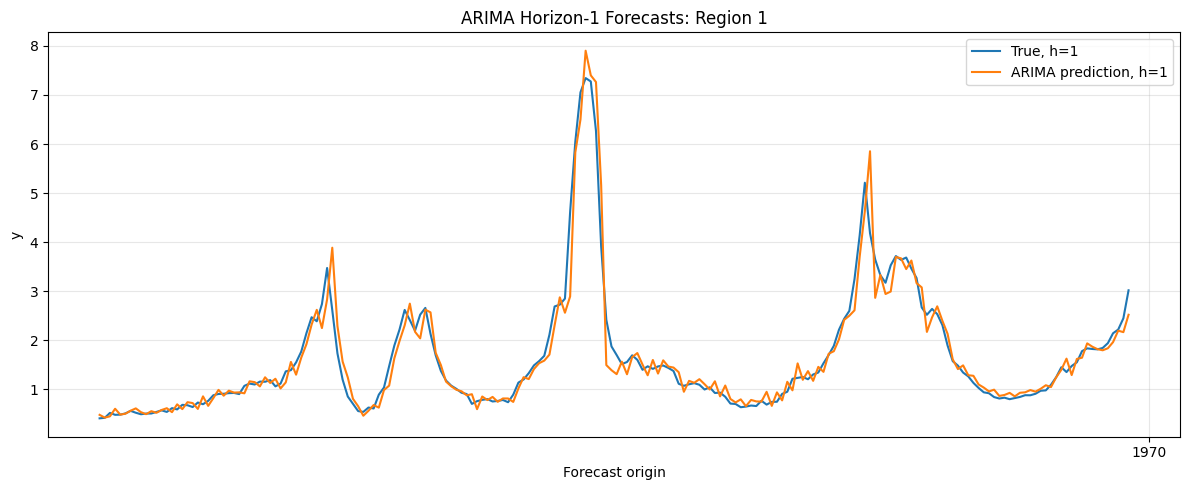

In [23]:
# Plot horizon-1 forecasts for one region.
region_to_plot = pred_df["unique_id"].iloc[0]

plot_df = pred_df[
    (pred_df["unique_id"] == region_to_plot) &
    (pred_df["horizon"] == 1)
].copy()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["origin_ds"], plot_df["y_true"], label="True, h=1")
plt.plot(plot_df["origin_ds"], plot_df["y_pred"], label="ARIMA prediction, h=1")
plt.title(f"ARIMA Horizon-1 Forecasts: {region_to_plot}")
plt.xlabel("Forecast origin")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Optional: compare several ARIMA orders

In [24]:
# This optional cell can be slow because it refits ARIMA many times.
# Use FIRST_N_TEST_WINDOWS_PER_SERIES = 20 in the config cell for a quick check.

candidate_orders = [
    (1, 0, 0),
    (2, 0, 0),
    (1, 0, 1),
    (2, 0, 1),
    (2, 0, 2),
    (3, 0, 1),
]

comparison_rows = []

# Set RUN_ORDER_COMPARISON = True when you want to run this block.
RUN_ORDER_COMPARISON = True

if RUN_ORDER_COMPARISON:
    for order in candidate_orders:
        print(f"\nRunning ARIMA order={order}")

        preds_order, statuses_order = run_arima_on_test_records(
            df=df,
            test_records=test_records,
            order=order,
            trend=ARIMA_TREND,
            use_full_history_up_to_origin=USE_FULL_HISTORY_UP_TO_ORIGIN,
            horizon=FUTURE,
        )

        res_order = summarize_forecasts(y_true, preds_order)
        mean_metrics = res_order[res_order["horizon"].eq("mean")].iloc[0].to_dict()

        comparison_rows.append({
            "order": str(order),
            "MSE": mean_metrics["MSE"],
            "MAE": mean_metrics["MAE"],
            "SMAPE": mean_metrics["SMAPE"],
            "NNSE": mean_metrics["NNSE"],
            "R2": mean_metrics["R2"],
            "n_arima_success": int(pd.Series(statuses_order).eq("arima").sum()),
            "n_total": len(statuses_order),
        })

    comparison_df = pd.DataFrame(comparison_rows).sort_values("MSE")
    comparison_path = OUTPUT_DIR / "arima_order_comparison.csv"
    comparison_df.to_csv(comparison_path, index=False)

    print(comparison_df)
    print("\nSaved order comparison to:", comparison_path)
else:
    print("Order comparison skipped. Set RUN_ORDER_COMPARISON = True to run.")


Running ARIMA order=(1, 0, 0)


Running ARIMA:   0%|          | 0/2000 [00:00<?, ?it/s]


Running ARIMA order=(2, 0, 0)


Running ARIMA:   0%|          | 0/2000 [00:00<?, ?it/s]


Running ARIMA order=(1, 0, 1)


...


Running ARIMA order=(2, 0, 2)


Running ARIMA:   0%|          | 0/2000 [00:00<?, ?it/s]


Running ARIMA order=(3, 0, 1)


Running ARIMA:   0%|          | 0/2000 [00:00<?, ?it/s]

       order       MSE       MAE      SMAPE      NNSE        R2  \
2  (1, 0, 1)  0.961911  0.482154  18.055329  0.739321  0.591202   
0  (1, 0, 0)  0.989416  0.510606  18.678417  0.730784  0.579053   
1  (2, 0, 0)  1.106670  0.481674  18.598594  0.719789  0.530237   
5  (3, 0, 1)  1.114770  0.488692  19.324273  0.718713  0.526815   
3  (2, 0, 1)  1.120434  0.489126  19.323747  0.717934  0.524426   
4  (2, 0, 2)  1.133177  0.501943  20.207653  0.715376  0.518951   

   n_arima_success  n_total  
2             2000     2000  
0             2000     2000  
1             2000     2000  
5             2000     2000  
3             2000     2000  
4             2000     2000  

Saved order comparison to: results_arima/arima_order_comparison.csv
